# Notebook 08 — Fine-tune Classification Head (Transfer Learning)

**Objective:** Fine-tune the pre-trained model from Notebook 07 in two stages:
1. **Stage 1 – Head-only training:** Freeze the backbone, train only the new classification head for a few epochs
2. **Stage 2 – Partial unfreeze:** Unfreeze the last few backbone layers and fine-tune the full tail end of the network

**Topics Covered:**
- Load pre-trained model config from Notebook 07
- Stage 1: Train only the new classification head (frozen backbone)
- Evaluate and plot Stage 1 training curves
- Stage 2: Unfreeze last N backbone layers for fine-tuning
- Save best model checkpoints
- Compare Stage 1 vs Stage 2 performance


## Import Packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

import json
import sys
import copy
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('Packages imported ✅')

Packages imported ✅


## Define Paths & Load Config from Notebook 07

In [2]:
def get_project_root():
    import os
    from pathlib import Path
    if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
        return Path(os.getcwd()).parent
    else:
        import IPython
        ip = IPython.get_ipython()
        nb_dir = Path(ip.run_line_magic('pwd', '')).resolve() if ip else Path('.').resolve()
        return nb_dir.parent

from pathlib import Path
import torch, json

PROJECT_ROOT = get_project_root()
DATA_DIR     = PROJECT_ROOT / 'data'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results'
SPLITS_DIR   = DATA_DIR / 'splits'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

config_path = MODELS_DIR / 'model_config.json'
try:
    with open(config_path) as f:
        cfg = json.load(f)
    print(f'✅ Config loaded from: {config_path}')
except FileNotFoundError:
    print('⚠️  Config not found — using defaults')
    cfg = {
        'model_choice' : 'resnet50',
        'num_classes'  : 38,
        'class_names'  : [],
        'img_size'     : 224,
        'batch_size'   : 64,
        'imagenet_mean': [0.485, 0.456, 0.406],
        'imagenet_std' : [0.229, 0.224, 0.225],
    }

MODEL_CHOICE  = cfg['model_choice']
NUM_CLASSES   = cfg['num_classes']
CLASS_NAMES   = cfg['class_names']
IMG_SIZE      = cfg['img_size']
BATCH_SIZE    = 64              # larger batch = fewer steps per epoch
IMAGENET_MEAN = cfg['imagenet_mean']
IMAGENET_STD  = cfg['imagenet_std']
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS   = 4               # max parallel data loading
SUBSET        = 0.2             # use 20% of data — stratified per class

print(f'Device     : {DEVICE}')
print(f'Model      : {MODEL_CHOICE.upper()}')
print(f'BATCH_SIZE : {BATCH_SIZE}')
print(f'SUBSET     : {SUBSET*100:.0f}% of data per split')
print(f'⚡ Fast mode: ~{int(54000*SUBSET/BATCH_SIZE)} steps/epoch')


✅ Config loaded from: /content/drive/MyDrive/Project2_AgroLens_AI/models/model_config.json
Device     : cuda
Model      : RESNET50
BATCH_SIZE : 64
SUBSET     : 20% of data per split
⚡ Fast mode: ~168 steps/epoch


## Fine-tuning Hyperparameters

In [3]:
# ─── Stage 1: Head-only training ─────────────────────────────────────────────
STAGE1_EPOCHS   = 2       # ⚡ Fast mode
STAGE1_LR       = 1e-3

# ─── Stage 2: Partial backbone unfreeze ──────────────────────────────────────
STAGE2_EPOCHS   = 3       # ⚡ Fast mode
STAGE2_LR       = 1e-4
UNFREEZE_LAYERS = 1       # Only last layer group — less compute

# ─── Shared ──────────────────────────────────────────────────────────────────
PATIENCE        = 2
NUM_WORKERS     = 4

print(f'Stage 1 → Epochs: {STAGE1_EPOCHS}, LR: {STAGE1_LR}')
print(f'Stage 2 → Epochs: {STAGE2_EPOCHS}, LR: {STAGE2_LR}, Unfreeze: {UNFREEZE_LAYERS} group')
print(f'Total epochs: {STAGE1_EPOCHS + STAGE2_EPOCHS}')


Stage 1 → Epochs: 2, LR: 0.001
Stage 2 → Epochs: 3, LR: 0.0001, Unfreeze: 1 group
Total epochs: 5


## Data Transforms & Loaders

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ─── Load datasets ────────────────────────────────────────────────────────────
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class PlantVillageDataset(Dataset):
    PATH_COLS  = ['path', 'filepath', 'file_path', 'image_path']
    LABEL_COLS = ['label_id', 'label_idx', 'class_id']

    def __init__(self, csv_path, transform=None, subset_fraction=1.0):
        df = pd.read_csv(csv_path).reset_index(drop=True)
        # Use a subset for speed if specified
        if subset_fraction < 1.0:
            df = df.groupby('label', group_keys=False).apply(
                lambda x: x.sample(frac=subset_fraction, random_state=42)
            ).reset_index(drop=True)
        self.df        = df
        self.transform = transform
        self.classes   = sorted(self.df['label'].unique().tolist())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        cols = self.df.columns.tolist()
        self.path_col  = next(c for c in self.PATH_COLS  if c in cols)
        self.label_col = next((c for c in self.LABEL_COLS if c in cols), None)
        if self.label_col is None:
            self.df['label_id'] = self.df['label'].map(self.class_to_idx)
            self.label_col = 'label_id'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row[self.path_col]).convert('RGB')
        label = int(row[self.label_col])
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = PlantVillageDataset(SPLITS_DIR / 'train.csv', transform=train_transforms, subset_fraction=SUBSET)
val_dataset   = PlantVillageDataset(SPLITS_DIR / 'val.csv',   transform=val_transforms,   subset_fraction=SUBSET)
test_dataset  = PlantVillageDataset(SPLITS_DIR / 'test.csv',  transform=val_transforms,   subset_fraction=SUBSET)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train : {len(train_dataset):,} samples  ({len(train_loader)} batches)')
print(f'Val   : {len(val_dataset):,} samples  ({len(val_loader)} batches)')
print(f'Test  : {len(test_dataset):,} samples  ({len(test_loader)} batches)')

Train : 2,890 samples  (46 batches)
Val   : 619 samples  (10 batches)
Test  : 619 samples  (10 batches)


## Build Model — Reproduce Architecture from Notebook 07

In [5]:
def build_model(model_choice: str, num_classes: int, freeze_backbone: bool = True):
    """
    Rebuild the architecture from Notebook 07.
    - Loads pre-trained ImageNet weights
    - Replaces the final FC with a new crop-disease head
    - Optionally freezes the backbone
    """
    if model_choice == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    elif model_choice == 'mobilenet':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
    else:
        raise ValueError(f'Unknown model choice: {model_choice}')

    return model


# Build with frozen backbone (Stage 1)
model = build_model(MODEL_CHOICE, NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Model : {MODEL_CHOICE.upper()}')
print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}  (head only)')
print(f'Frozen parameters    : {total - trainable:,}')

Model : RESNET50
Total parameters     : 24,036,431
Trainable parameters : 528,399  (head only)
Frozen parameters    : 23,508,032


## Training Utilities

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


def run_training_loop(model, train_loader, val_loader, criterion, optimizer,
                       scheduler, num_epochs, device, stage_name,
                       checkpoint_path, patience=3):
    """
    Full training loop with Early Stopping and best-model checkpointing.
    Returns history dict.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc  = 0.0
    epochs_no_imp = 0
    best_weights  = copy.deepcopy(model.state_dict())

    print(f'\n{"="*60}')
    print(f'  {stage_name}')
    print(f'{"="*60}')
    print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Val Loss":>10}  {"Train Acc":>10}  {"Val Acc":>10}  {"LR":>10}')
    print(f'{"-"*65}')

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        improved = '⬆' if val_acc > best_val_acc else ''
        print(f'{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  {train_acc:>10.4f}  {val_acc:>10.4f}  {current_lr:>10.2e}  {improved}')

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            best_weights  = copy.deepcopy(model.state_dict())
            torch.save(best_weights, checkpoint_path)
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1
            if epochs_no_imp >= patience:
                print(f'\n⏹  Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs)')
                break

    model.load_state_dict(best_weights)   # restore best
    print(f'\n✅ Best Val Accuracy: {best_val_acc:.4f}')
    print(f'✅ Checkpoint saved : {checkpoint_path}')
    return history


print('Training utilities defined ✅')

Training utilities defined ✅


## Stage 1 — Train Classification Head Only (Frozen Backbone)

In [7]:
# ─── Only the new head parameters require grad ────────────────────────────────
criterion  = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR,
    weight_decay=1e-4
)
scheduler1 = ReduceLROnPlateau(optimizer1, mode='min', factor=0.5, patience=2)

history_stage1 = run_training_loop(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    criterion   = criterion,
    optimizer   = optimizer1,
    scheduler   = scheduler1,
    num_epochs  = STAGE1_EPOCHS,
    device      = DEVICE,
    stage_name  = 'STAGE 1 — Head-only Training (Backbone Frozen)',
    checkpoint_path = MODELS_DIR / 'best_stage1.pth',
    patience    = PATIENCE
)


  STAGE 1 — Head-only Training (Backbone Frozen)
 Epoch  Train Loss    Val Loss   Train Acc     Val Acc          LR
-----------------------------------------------------------------


     1      2.0403      1.4355      0.3734      0.6090    1.00e-03  ⬆


     2      1.3025      1.0524      0.6087      0.6575    1.00e-03  ⬆



✅ Best Val Accuracy: 0.6575
✅ Checkpoint saved : /content/drive/MyDrive/Project2_AgroLens_AI/models/best_stage1.pth


## Stage 1 — Training Curves

Plot saved to: /content/drive/MyDrive/Project2_AgroLens_AI/results/stage1_curves.png


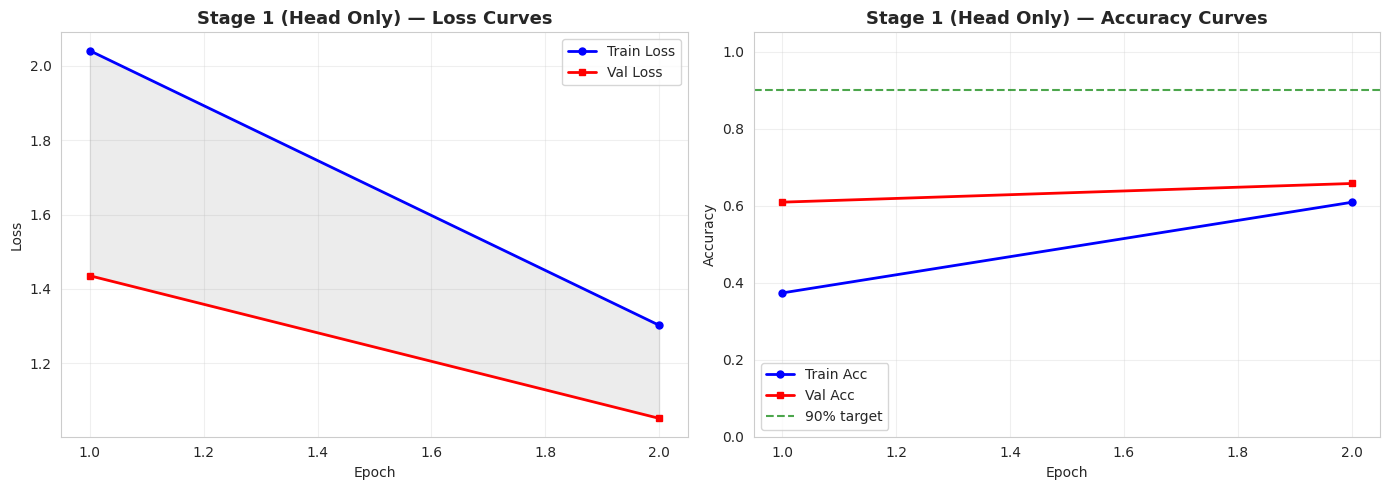

In [8]:
def plot_training_curves(history, stage_name, save_path=None):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', linewidth=2, markersize=5, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'r-s', linewidth=2, markersize=5, label='Val Loss')
    axes[0].fill_between(epochs, history['train_loss'], history['val_loss'], alpha=0.15, color='gray')
    axes[0].set_title(f'{stage_name} — Loss Curves', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-o', linewidth=2, markersize=5, label='Train Acc')
    axes[1].plot(epochs, history['val_acc'],   'r-s', linewidth=2, markersize=5, label='Val Acc')
    axes[1].axhline(y=0.90, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='90% target')
    axes[1].set_title(f'{stage_name} — Accuracy Curves', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Plot saved to: {save_path}')
    plt.show()


plot_training_curves(history_stage1, 'Stage 1 (Head Only)',
                     save_path=RESULTS_DIR / 'stage1_curves.png')

## Stage 2 — Unfreeze Last N Backbone Layers for Fine-tuning

In [9]:
def unfreeze_last_layers(model, model_choice, num_layer_groups):
    """
    Unfreeze the last `num_layer_groups` ResNet layer groups (layer4, layer3, ...)
    or the last `num_layer_groups` MobileNet feature blocks.
    """
    if model_choice == 'resnet50':
        # ResNet50 sequential groups: layer1, layer2, layer3, layer4 (index 0–3)
        layer_groups = [model.layer1, model.layer2, model.layer3, model.layer4]
        groups_to_unfreeze = layer_groups[-num_layer_groups:]   # last N groups

        for group in groups_to_unfreeze:
            for param in group.parameters():
                param.requires_grad = True

        # Also unfreeze the bn1 and the last batch norm if desired
        for param in model.bn1.parameters():
            param.requires_grad = False   # keep early layers frozen

        unfrozen_name = f'layer{5 - num_layer_groups}–layer4'

    elif model_choice == 'mobilenet':
        all_features = list(model.features.children())
        # Unfreeze last N feature blocks
        for block in all_features[-num_layer_groups:]:
            for param in block.parameters():
                param.requires_grad = True
        unfrozen_name = f'last {num_layer_groups} MobileNet feature blocks'
    else:
        raise ValueError(f'Unknown model choice: {model_choice}')

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Unfrozen: {unfrozen_name} + classification head')
    print(f'Trainable parameters : {trainable:,} / {total:,}')
    return model


# ─── Unfreeze last UNFREEZE_LAYERS groups ─────────────────────────────────────
model = unfreeze_last_layers(model, MODEL_CHOICE, UNFREEZE_LAYERS)

# ─── Use a lower LR; differential LR can be added for more control ───────────
optimizer2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE2_LR,
    weight_decay=1e-4
)
scheduler2 = ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=2)

print('\nStage 2 optimizer ready ✅')

Unfrozen: layer4–layer4 + classification head
Trainable parameters : 15,493,135 / 24,036,431

Stage 2 optimizer ready ✅


In [10]:
history_stage2 = run_training_loop(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    criterion   = criterion,
    optimizer   = optimizer2,
    scheduler   = scheduler2,
    num_epochs  = STAGE2_EPOCHS,
    device      = DEVICE,
    stage_name  = f'STAGE 2 — Fine-tuning (Last {UNFREEZE_LAYERS} Layer Groups Unfrozen)',
    checkpoint_path = MODELS_DIR / 'best_stage2.pth',
    patience    = PATIENCE
)


  STAGE 2 — Fine-tuning (Last 1 Layer Groups Unfrozen)
 Epoch  Train Loss    Val Loss   Train Acc     Val Acc          LR
-----------------------------------------------------------------


     1      0.6978      0.3193      0.7830      0.9079    1.00e-04  ⬆


     2      0.3558      0.2014      0.8869      0.9338    1.00e-04  ⬆


     3      0.2408      0.1742      0.9298      0.9257    1.00e-04  

✅ Best Val Accuracy: 0.9338
✅ Checkpoint saved : /content/drive/MyDrive/Project2_AgroLens_AI/models/best_stage2.pth


## Stage 2 — Training Curves

Plot saved to: /content/drive/MyDrive/Project2_AgroLens_AI/results/stage2_curves.png


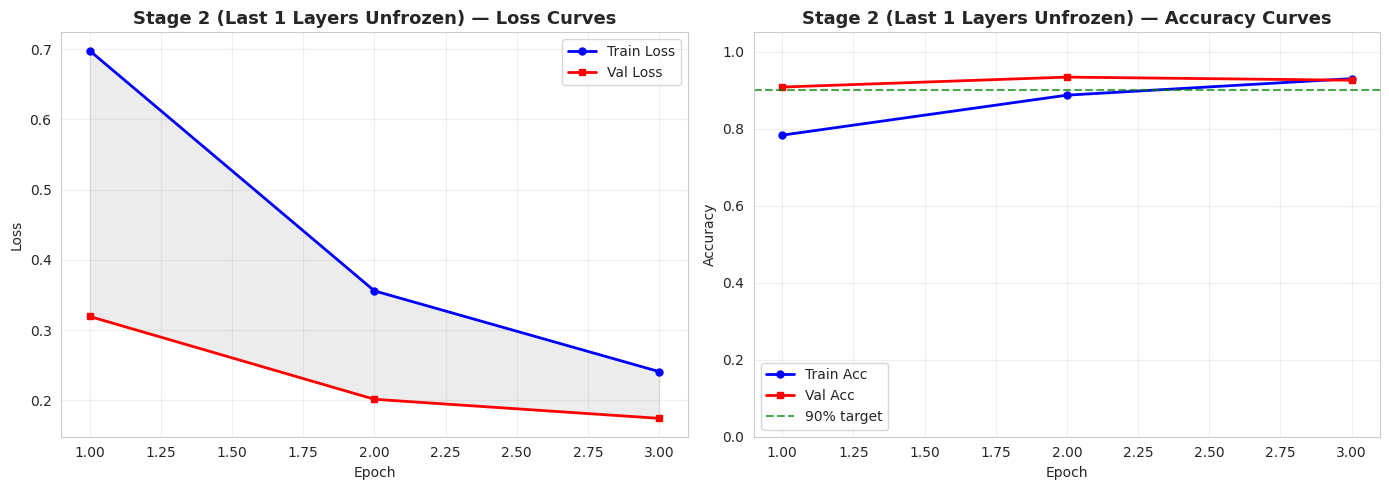

In [11]:
plot_training_curves(history_stage2,
                     f'Stage 2 (Last {UNFREEZE_LAYERS} Layers Unfrozen)',
                     save_path=RESULTS_DIR / 'stage2_curves.png')

## Stage 1 vs Stage 2 — Side-by-side Comparison

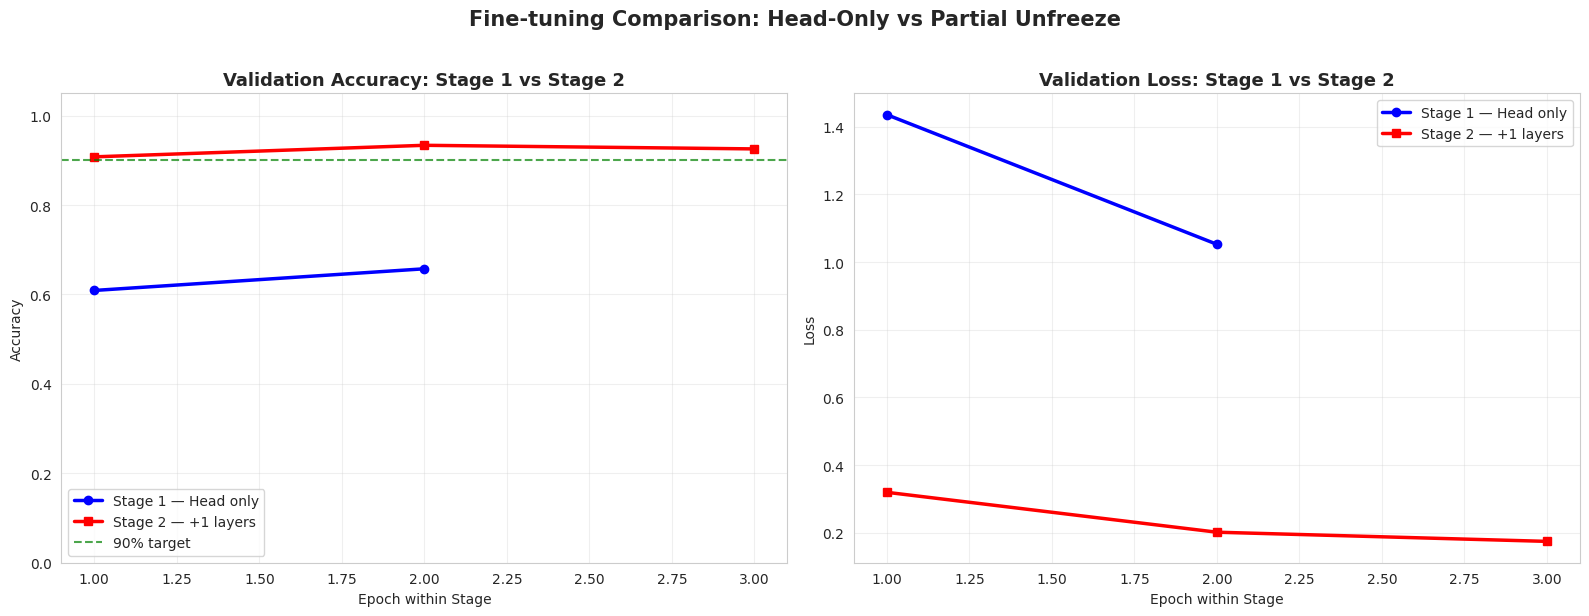


📊 Stage 1 best val acc : 0.6575
📊 Stage 2 best val acc : 0.9338


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Val Accuracy comparison ──────────────────────────────────────────────────
e1 = range(1, len(history_stage1['val_acc']) + 1)
e2 = range(1, len(history_stage2['val_acc']) + 1)

axes[0].plot(e1, history_stage1['val_acc'], 'b-o', linewidth=2.5, markersize=6, label='Stage 1 — Head only')
axes[0].plot(e2, history_stage2['val_acc'], 'r-s', linewidth=2.5, markersize=6, label=f'Stage 2 — +{UNFREEZE_LAYERS} layers')
axes[0].axhline(y=0.90, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='90% target')
axes[0].set_title('Validation Accuracy: Stage 1 vs Stage 2', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch within Stage'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ─── Val Loss comparison ──────────────────────────────────────────────────────
axes[1].plot(e1, history_stage1['val_loss'], 'b-o', linewidth=2.5, markersize=6, label='Stage 1 — Head only')
axes[1].plot(e2, history_stage2['val_loss'], 'r-s', linewidth=2.5, markersize=6, label=f'Stage 2 — +{UNFREEZE_LAYERS} layers')
axes[1].set_title('Validation Loss: Stage 1 vs Stage 2', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch within Stage'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Fine-tuning Comparison: Head-Only vs Partial Unfreeze',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'stage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Stage 1 best val acc : {max(history_stage1["val_acc"]):.4f}')
print(f'📊 Stage 2 best val acc : {max(history_stage2["val_acc"]):.4f}')

## Final Evaluation on Test Set

In [13]:
# ─── Load best Stage 2 checkpoint for test evaluation ────────────────────────
best_ckpt = MODELS_DIR / 'best_stage2.pth'
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

print('=' * 50)
print('  FINAL TEST SET RESULTS (Stage 2 Best Model)')
print('=' * 50)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

target_met = '✅ TARGET MET!' if test_acc >= 0.90 else '❌ Below 90% — try more unfreezing or Notebook 09 tuning'
print(f'\n  {target_met}')

  FINAL TEST SET RESULTS (Stage 2 Best Model)
  Test Loss     : 0.2018
  Test Accuracy : 0.9370 (93.70%)

  ✅ TARGET MET!


## Save Fine-tuning History & Updated Config

In [14]:
# ─── Save combined history ────────────────────────────────────────────────────
finetune_history = {
    'stage1': history_stage1,
    'stage2': history_stage2,
    'stage1_best_val_acc': max(history_stage1['val_acc']),
    'stage2_best_val_acc': max(history_stage2['val_acc']),
    'test_acc': test_acc,
    'test_loss': test_loss
}

with open(MODELS_DIR / 'finetune_history.json', 'w') as f:
    json.dump(finetune_history, f, indent=4)
print('Fine-tuning history saved to: finetune_history.json ✅')

# ─── Update config with fine-tuned model info ─────────────────────────────────
cfg.update({
    'frozen_backbone'    : False,
    'unfrozen_layers'    : UNFREEZE_LAYERS,
    'stage2_best_val_acc': max(history_stage2['val_acc']),
    'best_model_path'    : str(best_ckpt)
})
with open(MODELS_DIR / 'model_config.json', 'w') as f:
    json.dump(cfg, f, indent=4)
print('Config updated ✅')

print('\n🎉 Notebook 08 complete — ready for Notebook 09 (Hyperparameter Tuning)')

Fine-tuning history saved to: finetune_history.json ✅
Config updated ✅

🎉 Notebook 08 complete — ready for Notebook 09 (Hyperparameter Tuning)
